Booting Quantum Simulation with Magnetic Field B = 0.6...
Simulation complete.


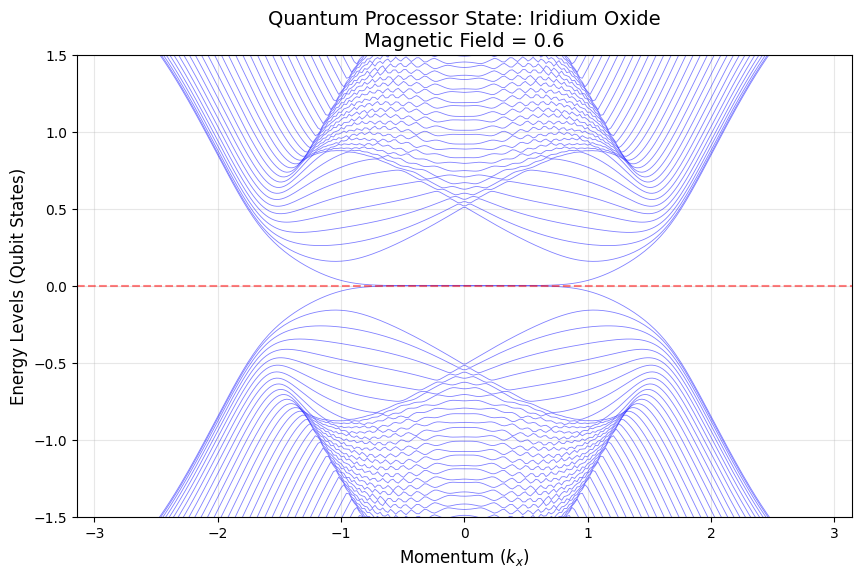

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS (Ege & Your Setup) ---
width = 50           # Ribbon width
k_points = 300       # Higher resolution
A = 0.5              # Iridium Spin-Orbit Coupling
B = 1.0              # Band parameters
M = -0.5             # Topological Phase (Inverted Gap)

# --- NEW QUANTUM CONTROL PARAMETER ---
# This simulates applying a magnetic field to the processor.
# Set to 0.0 to see the "protected" state.
# Set to 0.2 or 0.4 to see "qubit manipulation" (Band Splitting).
magnetic_field = 0.6 

k_values = np.linspace(-np.pi, np.pi, k_points)
energies = []

print(f"Booting Quantum Simulation with Magnetic Field B = {magnetic_field}...")

for kx in k_values:
    H = np.zeros((2 * width, 2 * width), dtype=complex)
    
    for y in range(width):
        i = 2 * y
        
        # 1. Base Energy + Mass
        epsilon_k = M - 2 * B * (1 - np.cos(kx))
        
        # 2. Add MAGNETIC FIELD (Zeeman Split)
        # This acts as our "Write" operation on the Qubits
        H[i, i]     =  epsilon_k + magnetic_field  # Shift Spin Up
        H[i+1, i+1] = -epsilon_k - magnetic_field  # Shift Spin Down
        
        # 3. Nearest Neighbor Hopping
        if y < width - 1:
            j = 2 * (y + 1)
            H[i, j] = B; H[j, i] = B
            H[i+1, j+1] = -B; H[j+1, i+1] = -B
            
            # Spin-Orbit Coupling (Iridium Physics)
            H[i, j+1] = -0.5j * A
            H[j+1, i] =  0.5j * A
            H[i+1, j] = -0.5j * A
            H[j, i+1] =  0.5j * A

    # 4. Spin-Orbit in x-direction
    for y in range(width):
        i = 2 * y
        H[i, i+1] += A * np.sin(kx)
        H[i+1, i] += A * np.sin(kx)

    eigenvalues = np.linalg.eigvalsh(H)
    energies.append(eigenvalues)

# --- VISUALIZATION ---
energies = np.array(energies)
plt.figure(figsize=(10, 6))
plt.title(f"Quantum Processor State: Iridium Oxide\nMagnetic Field = {magnetic_field}", fontsize=14)
plt.xlabel("Momentum ($k_x$)", fontsize=12)
plt.ylabel("Energy Levels (Qubit States)", fontsize=12)

# Plot bands
plt.plot(k_values, energies, color='blue', alpha=0.5, linewidth=0.6)

# Highlight the operational window
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label="Fermi Level")
plt.grid(True, alpha=0.3)
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.5, 1.5)

print("Simulation complete.")
plt.show()